# ADMM ghost imaging solve

For each GMD bin we form

    M = Cov(A)    = <AtA> - <A><A>ᵀ        (n_pixels, n_pixels)
    B = Cov(A,D)  = <AtD> - <A><D>ᵀ        (n_pixels, n_tof)

and solve

    min_X  ½||M X - B||² + ½ λ_p ||D_p X||² + ½ λ_t ||X D_tᵀ||² + λ_s ||X||_1

via ADMM (see `admm_ghost.py`). The two smoothness terms penalise
curvature along the VLS-pixel and eTOF axes independently, and the
ℓ₁ term encourages a sparse spectral kernel.

In [1]:
import sys
from pathlib import Path
_REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(_REPO_ROOT / "analysis" / "scripts"))

import numpy as np
import matplotlib.pyplot as plt

import config
from compute_aggregates import load_aggregates
from admm_ghost import solve_admm

%matplotlib inline

## Parameters

Regularisation weights are problem-scale-dependent. Sensible starting
points for the test data: smoothness ~1e3, sparsity tuned to give a
shrinkage threshold `λ_s/ρ` on the order of a few percent of the
typical |X| magnitude.

`rho` should be on the order of a representative eigenvalue of
`MtM + λ_p D_pᵀD_p`; too small slows the data fit, too large slows
the ℓ₁ shrinkage.

In [2]:
AGGREGATES_FILE = config.COMBINED_DIR / "test_config2_aggregates.h5"

# Bin to inspect in detail (also used to set lambda scales).
FOCUS_BIN = 3

# Regularisation weights.
LAMBDA_SMOOTH_PIXEL = 1e3
LAMBDA_SMOOTH_TOF   = 1e3
LAMBDA_SPARSE       = 5e-2     # tuned to shrink at a few percent of |X|

# ADMM penalty parameter.
RHO = 1e4

# Solver controls.
MAX_ITER   = 500
DIFF_ORDER = 2          # 1 for first difference, 2 for Laplacian
TOL        = 1e-4

CLIM_PERCENTILE = 99.0

## Load aggregates

In [3]:
agg = load_aggregates(AGGREGATES_FILE)
print(f"file          : {AGGREGATES_FILE}")
print(f"n_pixels      : {agg.n_pixels}")
print(f"n_tof         : {agg.n_tof}  ({agg.tof_edges[0]:.0f} .. {agg.tof_edges[-1]:.0f} ns)")
print(f"n_gmd_bins    : {agg.n_gmd_bins}")
print(f"shots per bin : {agg.n_per_bin}")

file          : C:\Users\oga17\OneDrive - Imperial College London\Python\glycine2026\11022188\processed\combined\test_config2_aggregates.h5
n_pixels      : 120
n_tof         : 125  (500 .. 1750 ns)
n_gmd_bins    : 7
shots per bin : [ 70372  61414  95121 114629  73175  19667   1793]


## Form per-bin covariances

In [4]:
cov_AA = agg.AtA - agg.A[:, :, None] * agg.A[:, None, :]
cov_AD = agg.AtD - agg.A[:, :, None] * agg.D[:, None, :]

M = cov_AA[FOCUS_BIN]
B = cov_AD[FOCUS_BIN]

eigM = np.linalg.eigvalsh(M)
X_ref = np.linalg.solve(M, B)   # un-regularised reference
print(f"bin {FOCUS_BIN}  GMD [{agg.gmd_edges[FOCUS_BIN]:.3f}, {agg.gmd_edges[FOCUS_BIN+1]:.3f})  "
      f"n={int(agg.n_per_bin[FOCUS_BIN])}")
print(f"  M eig range : {eigM.min():.2e} .. {eigM.max():.2e}")
print(f"  |B|_F       : {np.linalg.norm(B):.3e}")
print(f"  unreg |X|_F : {np.linalg.norm(X_ref):.3e}")
print(f"  unreg mean|X|: {np.abs(X_ref).mean():.3e}")

bin 3  GMD [0.200, 0.400)  n=114629
  M eig range : 2.93e+02 .. 4.04e+07
  |B|_F       : 1.275e+02
  unreg |X|_F : 2.075e-03
  unreg mean|X|: 1.113e-05


## Solve for the focus bin

In [5]:
res = solve_admm(
    M, B,
    lambda_smooth_pixel=LAMBDA_SMOOTH_PIXEL,
    lambda_smooth_tof=LAMBDA_SMOOTH_TOF,
    lambda_sparse=LAMBDA_SPARSE,
    rho=RHO,
    diff_order=DIFF_ORDER,
    max_iter=MAX_ITER,
    tol_primal=TOL,
    tol_dual=TOL,
)

X = res.X
rel_res = float(np.linalg.norm(M @ X - B) / np.linalg.norm(B))
sparse_frac = float((np.abs(X) < 1e-6).mean())
print(f"converged={res.converged} in {res.n_iter} iters")
print(f"final |X|_F        : {np.linalg.norm(X):.3e}")
print(f"||MX-B|| / ||B||   : {rel_res:.3e}")
print(f"sparsity (|X|<1e-6): {sparse_frac:.2%}")
print(f"final J(X)         : {res.history['objective'][-1]:.3e}")

converged=True in 75 iters
final |X|_F        : 1.959e-03
||MX-B|| / ||B||   : 5.000e-04
sparsity (|X|<1e-6): 12.25%
final J(X)         : 3.373e-02


## Reconstruction

Side-by-side: un-regularised Tikhonov reference (`M⁻¹ B`) vs the ADMM
kernel `X*`. Diverging colormap centred at zero; same colour scale on
both so the regularisation effect is directly visible.

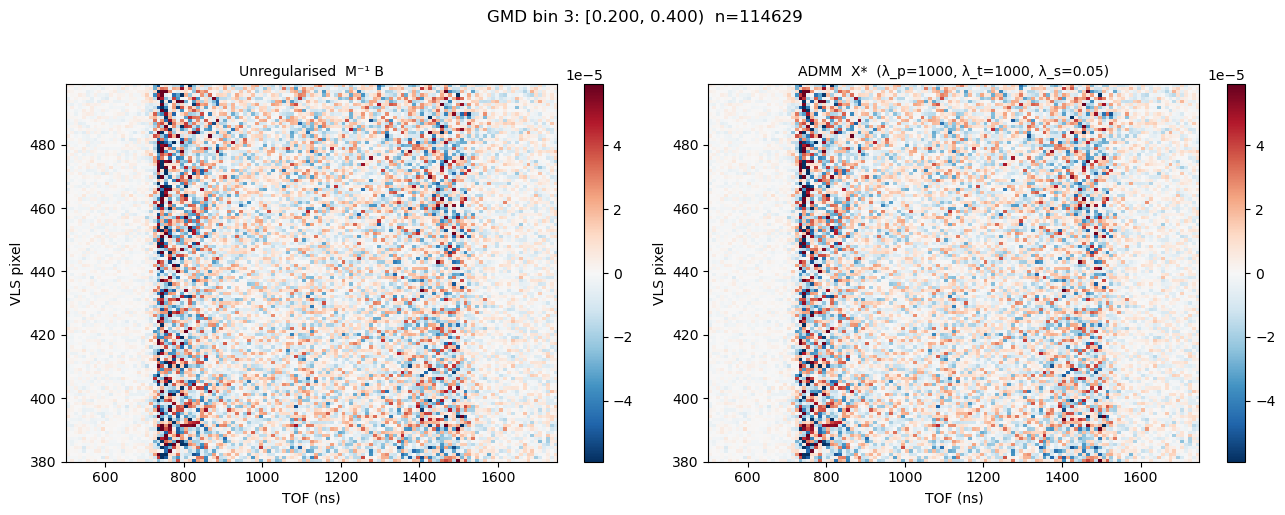

In [6]:
extent = [agg.tof_edges[0], agg.tof_edges[-1],
          agg.vls_pixels[0], agg.vls_pixels[-1]]
vmax = float(np.nanpercentile(np.abs(X_ref), CLIM_PERCENTILE))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, M_plot, title in [
    (axes[0], X_ref, "Unregularised  M\u207b\u00b9 B"),
    (axes[1], X,     f"ADMM  X*  (\u03bb_p={LAMBDA_SMOOTH_PIXEL:g}, "
                     f"\u03bb_t={LAMBDA_SMOOTH_TOF:g}, "
                     f"\u03bb_s={LAMBDA_SPARSE:g})"),
]:
    im = ax.imshow(M_plot, origin="lower", cmap="RdBu_r",
                   vmin=-vmax, vmax=vmax, extent=extent, aspect="auto")
    ax.set_xlabel("TOF (ns)")
    ax.set_ylabel("VLS pixel")
    ax.set_title(title, fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(f"GMD bin {FOCUS_BIN}: [{agg.gmd_edges[FOCUS_BIN]:.3f}, "
             f"{agg.gmd_edges[FOCUS_BIN+1]:.3f})  n={int(agg.n_per_bin[FOCUS_BIN])}",
             y=1.02)
fig.tight_layout()
plt.show()

## Convergence

Primal residual `‖X − Z‖_F`, dual residual `ρ‖Z − Z_prev‖_F`, and
the objective `J(X)`. Healthy ADMM has both residuals dropping
monotonically on a log scale and `J` falling to a plateau.

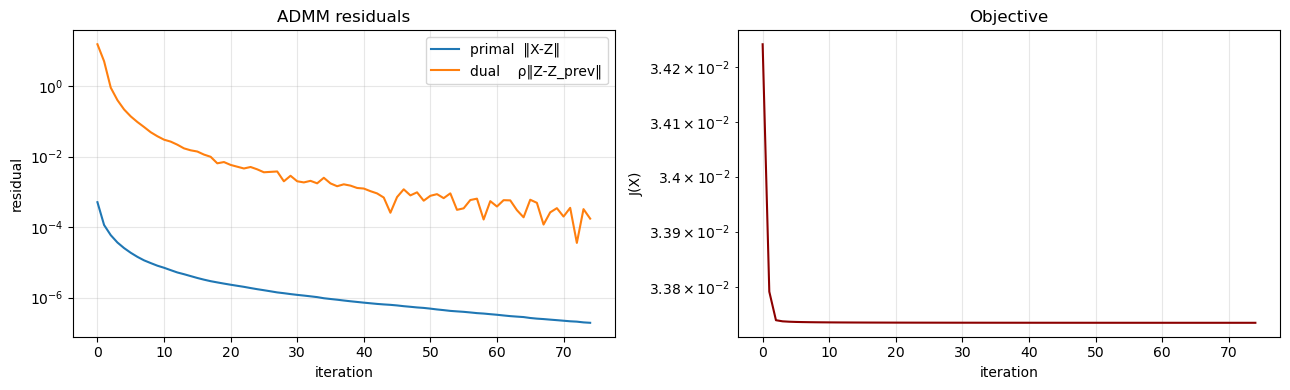

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.semilogy(res.history["primal"], label="primal  \u2016X-Z\u2016")
ax1.semilogy(res.history["dual"],   label="dual    \u03c1\u2016Z-Z_prev\u2016")
ax1.set_xlabel("iteration")
ax1.set_ylabel("residual")
ax1.set_title("ADMM residuals")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.semilogy(res.history["objective"], color="darkred")
ax2.set_xlabel("iteration")
ax2.set_ylabel("J(X)")
ax2.set_title("Objective")
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Solve for every GMD bin

Re-run the solver with the same regularisation across each bin. Empty
or sub-threshold bins are skipped.

In [8]:
X_per_bin = np.full_like(cov_AD, np.nan)
summary   = []

for b in range(agg.n_gmd_bins):
    n_b = int(agg.n_per_bin[b])
    if n_b == 0:
        summary.append((b, n_b, np.nan, np.nan, 0, False))
        continue
    M_b = cov_AA[b]
    B_b = cov_AD[b]
    r = solve_admm(
        M_b, B_b,
        lambda_smooth_pixel=LAMBDA_SMOOTH_PIXEL,
        lambda_smooth_tof=LAMBDA_SMOOTH_TOF,
        lambda_sparse=LAMBDA_SPARSE,
        rho=RHO,
        diff_order=DIFF_ORDER,
        max_iter=MAX_ITER,
        tol_primal=TOL, tol_dual=TOL,
        track_objective=False,
    )
    X_per_bin[b] = r.X
    rel_res = float(np.linalg.norm(M_b @ r.X - B_b) / np.linalg.norm(B_b))
    summary.append((b, n_b, float(np.linalg.norm(r.X)), rel_res, r.n_iter, r.converged))

print(f"{'bin':>3}  {'n_shots':>8}  {'|X|_F':>10}  {'rel_res':>9}  "
      f"{'iters':>6}  conv")
for b, n, fro, rr, it, cv in summary:
    print(f"{b:>3}  {n:>8d}  {fro:>10.3e}  {rr:>9.3e}  {it:>6d}  {cv}")

bin   n_shots       |X|_F    rel_res   iters  conv
  0     70372   2.197e-03  7.012e-04      68  True
  1     61414   2.460e-03  6.700e-04      63  True
  2     95121   2.098e-03  5.565e-04      74  True
  3    114629   1.959e-03  5.000e-04      75  True
  4     73175   2.596e-03  6.599e-04      62  True
  5     19667   5.135e-03  1.307e-03      38  True
  6      1793   1.783e-02  2.501e-03      40  True


## All-bin reconstructions

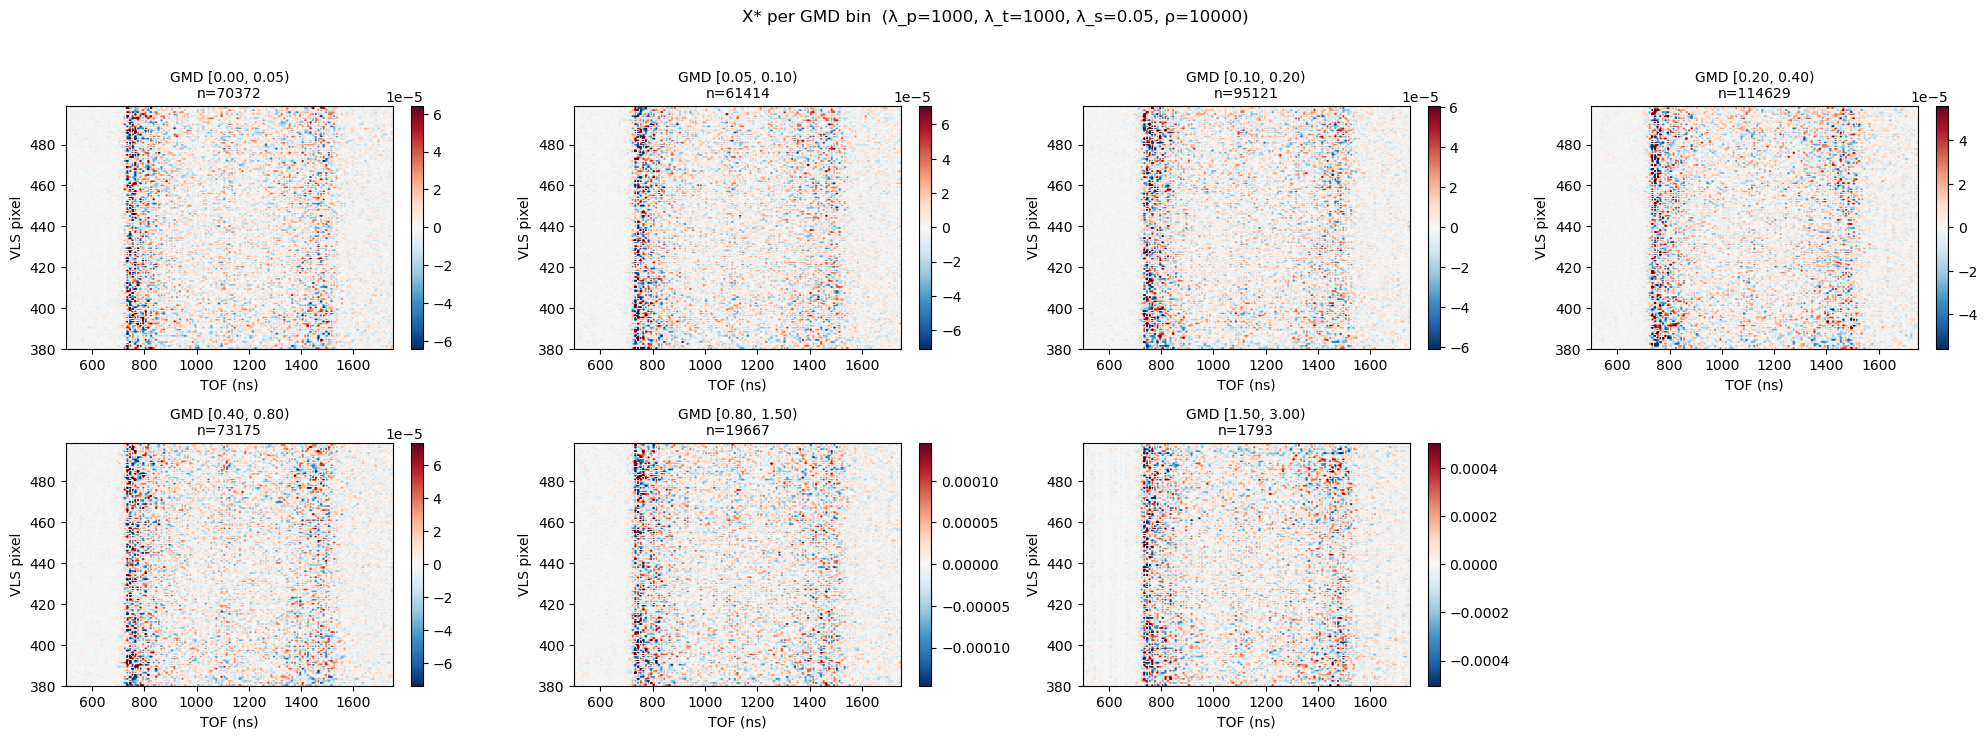

In [9]:
n = agg.n_gmd_bins
cols = min(4, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5.0 * cols, 3.6 * rows))
axes_flat = np.atleast_1d(axes).ravel()

extent = [agg.tof_edges[0], agg.tof_edges[-1],
          agg.vls_pixels[0], agg.vls_pixels[-1]]

for b in range(n):
    ax = axes_flat[b]
    Xb = X_per_bin[b]
    if not np.isfinite(Xb).any():
        ax.set_title(f"bin {b}  (empty)")
        ax.axis("off")
        continue
    vmax = float(np.nanpercentile(np.abs(Xb), CLIM_PERCENTILE))
    if vmax == 0:
        vmax = float(np.abs(Xb).max()) or 1.0
    im = ax.imshow(Xb, origin="lower", cmap="RdBu_r",
                   vmin=-vmax, vmax=vmax, extent=extent, aspect="auto")
    ax.set_xlabel("TOF (ns)")
    ax.set_ylabel("VLS pixel")
    ax.set_title(f"GMD [{agg.gmd_edges[b]:.2f}, {agg.gmd_edges[b+1]:.2f})\n"
                 f"n={int(agg.n_per_bin[b])}", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046)

for ax in axes_flat[n:]:
    ax.axis("off")

fig.suptitle("X* per GMD bin  "
             f"(\u03bb_p={LAMBDA_SMOOTH_PIXEL:g}, \u03bb_t={LAMBDA_SMOOTH_TOF:g}, "
             f"\u03bb_s={LAMBDA_SPARSE:g}, \u03c1={RHO:g})",
             y=1.02)
fig.tight_layout()
plt.show()